1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import chi2_contingency

# Configuración visual
sns.set_theme(style="whitegrid")
%matplotlib inline

# 1. Cargar el dataset
df = pd.read_csv('credit_risk_dataset.csv')

print("=== MINI-EDA (Estructura Global) ===")
# Tamaño del dataset
print(f"Dimensiones globales del dataset: {df.shape}")

# Tipos de datos
print("\n--- Tipos de Datos por Columna ---")
print(df.dtypes)

# Distribución de la variable objetivo para la estratificación
print("\n--- Distribución de la Variable Objetivo (loan_status) ---")
print(df['loan_status'].value_counts(normalize=True) * 100)

=== MINI-EDA (Estructura Global) ===
Dimensiones globales del dataset: (32581, 12)

--- Tipos de Datos por Columna ---
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

--- Distribución de la Variable Objetivo (loan_status) ---
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


Diccionario de datos y eliminación de variable para evitar la fuga de datos:

| Variable | Descripción |
| :--- | :--- |
| `person_age` | Edad del solicitante del préstamo (en años). |
| `person_income` | Ingresos anuales declarados por el solicitante. |
| `person_home_ownership` | Situación de la vivienda del solicitante (ej. RENT, MORTGAGE, OWN, OTHER). |
| `person_emp_length` | Antigüedad laboral del solicitante (en años). |
| `loan_intent` | El motivo o destino por el cual se solicita el préstamo (ej. PERSONAL, EDUCATION, MEDICAL, etc.). |
| `loan_grade` | Grado o calificación de riesgo asignada al préstamo por la institución financiera (de la A a la G). |
| `loan_amnt` | Monto total del préstamo solicitado. |
| `loan_int_rate` | Tasa de interés asociada al préstamo (en porcentaje). |
| `loan_status` | Estado actual del préstamo. `0` = Pagado/Al corriente, `1` = En incumplimiento o impago (Tu variable objetivo). |
| `loan_percent_income` | Relación entre el monto del préstamo y el ingreso anual del solicitante (`loan_amnt` / `person_income`). |
| `cb_person_default_on_file` | Indica si el solicitante tiene un historial de impago registrado en el buró de crédito (Y = Sí, N = No). |
| `cb_person_cred_hist_length` | Antigüedad de la historia crediticia del solicitante (en años). |

Para evitar el Data Leakage (Fuga de datos), eliminaremos la variable 'loan_int_rate' (Tasa de interés del préstamo) ya que las tasas de interés las define el banco en función del riesgo detectado en el cliente.

Asimismo, eliminaremos la variable 'loan_grade', ya que cuando llegue un cliente nuevo a pedir un crédito, todavía no tendrá un grado asignado, por lo que el modelo no podrá funcionar.

2

In [ ]:
# Separar características (X) y objetivo (y)
X_global = df.drop(columns=['loan_status', 'loan_int_rate', 'loan_grade'])
y_global = df['loan_status']

# Dividir en entrenamiento (70%) y prueba (30%) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X_global,
    y_global,
    test_size=0.30,
    random_state=42,
    stratify=y_global
)

# CORRECCIÓN: Aseguramos copias independientes para evitar advertencias de Pandas en las celdas de limpieza
X_train = X_train.copy()
X_test = X_test.copy()

print("=== Datos Separados con Éxito y Protegidos ===")
print(f"X_train (Entrenamiento): {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test (Prueba/Validación): {X_test.shape}  | y_test: {y_test.shape}")

=== Datos Separados con Éxito y Protegidos ===
X_train (Entrenamiento): (22806, 9) | y_train: (22806,)
X_test (Prueba/Validación): (9775, 9)  | y_test: (9775,)


3

In [ ]:
# Combinamos temporalmente para facilitar el EDA con la variable objetivo
df_train_eda = X_train.copy()
df_train_eda['loan_status'] = y_train

print("=== EDA PROFUNDO: Resumen Estadístico (TRAIN) ===")
display(df_train_eda.describe().T)

print("\n=== EDA PROFUNDO: Conteo de Valores Nulos (TRAIN) ===")
nulos_train = df_train_eda.isnull().sum()
print(nulos_train[nulos_train > 0])

=== EDA PROFUNDO: Resumen Estadístico (TRAIN) ===


,count,mean,std,min,25%,50%,75%,max
person_age,22806.0,27.722880,6.336638,20.0,23.00,26.00,30.00,144.00
person_income,22806.0,66206.972463,63874.561464,4000.0,38524.75,55000.00,79635.00,6000000.00
person_emp_length,22167.0,4.796905,4.120061,0.0,2.00,4.00,7.00,123.00
loan_amnt,22806.0,9598.740463,6313.133319,500.0,5000.00,8000.00,12250.00,35000.00
loan_percent_income,22806.0,0.170173,0.106759,0.0,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,22806.0,5.797992,4.056109,2.0,3.00,4.00,8.00,30.00
loan_status,22806.0,0.218144,0.412995,0.0,0.00,0.00,0.00,1.00



=== EDA PROFUNDO: Conteo de Valores Nulos (TRAIN) ===
person_emp_length    639
dtype: int64


4

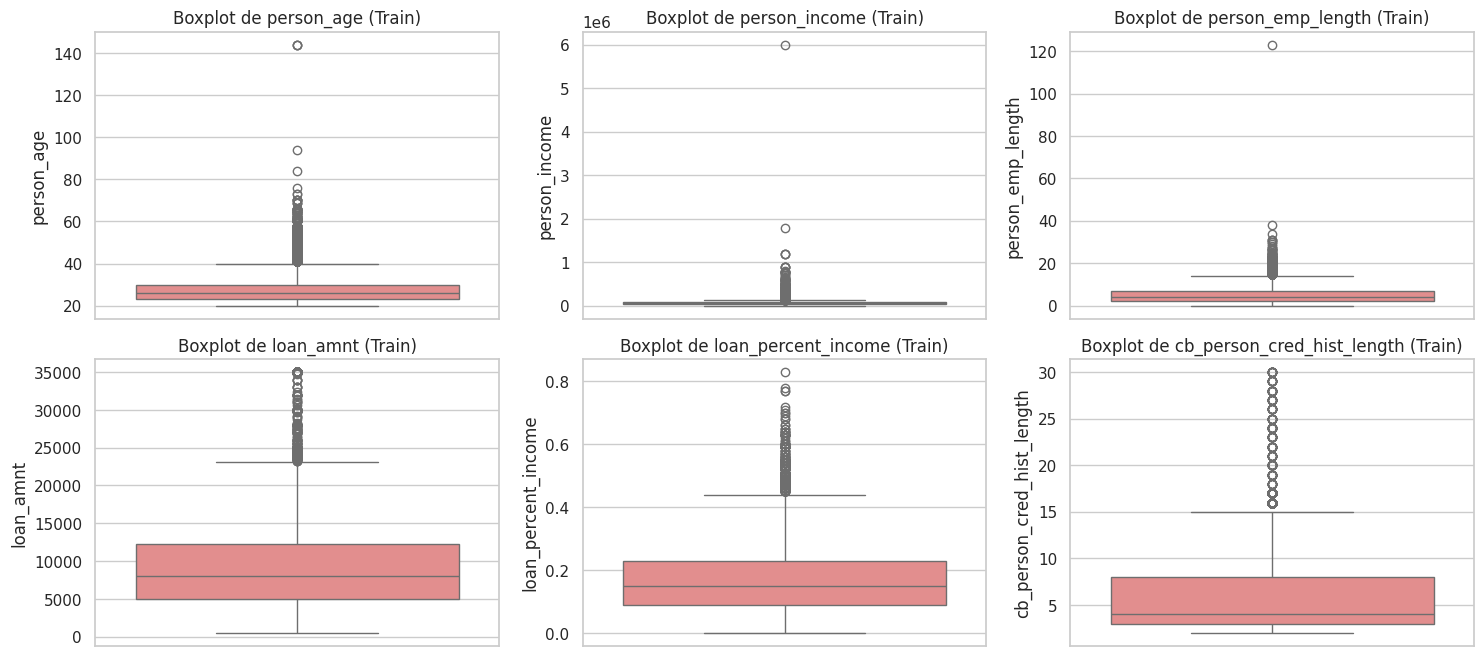

In [ ]:
# Identificar columnas numéricas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 1. Boxplots para detección de Outliers/Ruido
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_train_eda[col], color='lightcoral')
    plt.title(f'Boxplot de {col} (Train)')
plt.tight_layout()
plt.show()

5

In [ ]:
print(f"\nRegistros antes de limpieza por ruido -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# 1. Calcular mediana con el X_train ORIGINAL (Sin nulos y antes de alterar nada)
mediana_emp_train = X_train['person_emp_length'].median()

# 2. DEFINIR FILTROS PRIMERO (Sobre los datos puros para detectar el ruido real)
# Nota: Usamos .fillna() temporalmente dentro del filtro para que los NaN no rompan la comparación matemática,
# pero sin alterar el DataFrame aún.
filtro_ruido_train = (X_train['person_age'] <= 100) & (X_train['person_emp_length'].fillna(0) <= (X_train['person_age'] - 14))
filtro_ruido_test = (X_test['person_age'] <= 100) & (X_test['person_emp_length'].fillna(0) <= (X_test['person_age'] - 14))

limite_ingresos_train = X_train['person_income'].quantile(0.999)
filtro_ingreso_train = X_train['person_income'] <= limite_ingresos_train
filtro_ingreso_test = X_test['person_income'] <= limite_ingresos_train

# 3. Aplicar filtros (Eliminar filas ruidosas)
X_train = X_train[filtro_ruido_train & filtro_ingreso_train]
y_train = y_train[X_train.index]

X_test = X_test[filtro_ruido_test & filtro_ingreso_test]
y_test = y_test[X_test.index]

# 4. IMPUTAR NULOS AL FINAL (Solo en los registros limpios y sanos)
X_train['person_emp_length'] = X_train['person_emp_length'].fillna(mediana_emp_train)
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(mediana_emp_train)

print(f"Registros después de limpieza -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

print("\n=== PROCESAMIENTO FINALIZADO ===")
print(f"Valores nulos restantes en X_train: {X_train.isnull().sum().sum()}")
print(f"Valores nulos restantes en X_test: {X_test.isnull().sum().sum()}")
print(f"Dimensiones finales -> X_train: {X_train.shape} | X_test: {X_test.shape}")


Registros antes de limpieza por ruido -> Train: 22806, Test: 9775
Registros después de limpieza -> Train: 22780, Test: 9760

=== PROCESAMIENTO FINALIZADO ===
Valores nulos restantes en X_train: 0
Valores nulos restantes en X_test: 0
Dimensiones finales -> X_train: (22780, 9) | X_test: (9760, 9)


6

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Recuperamos las categóricas vigentes del set de entrenamiento EDA
# (Recordemos que df_train_eda se construyó en la celda 3 a partir del X_train de ese momento)
cat_cols = [col for col in X_train.select_dtypes(include=['object', 'category']).columns]

print("=== REVISIÓN PREVIA DE VARIABLES CATEGÓRICAS ===")

for col in cat_cols:
    # Creamos la tabla de contingencia usando los índices alineados tras la limpieza
    contingency_table = pd.crosstab(X_train[col], y_train)

    # Ejecutamos la prueba Chi-Cuadrado
    chi2, p_valor, dof, expected = chi2_contingency(contingency_table)

    # Cálculo de Information Value (IV)
    counts = pd.crosstab(X_train[col], y_train)
    counts = counts.replace(0, 0.5) # Evitar divisiones por cero indeterminadas

    prob_buenos = counts[0] / counts[0].sum()
    prob_malos = counts[1] / counts[1].sum()

    woe = np.log(prob_buenos / prob_malos)
    iv = ((prob_buenos - prob_malos) * woe).sum()

    # Clasificación estándar de la industria financiera para el IV
    if iv < 0.02:   fuerza = "Inútil para predecir"
    elif iv < 0.1:  fuerza = "Poder predictivo Débil"
    elif iv < 0.3:  fuerza = "Poder predictivo Mediano"
    else:           fuerza = "Poder predictivo Fuerte"

    print(f"\nVariable: '{col}'")
    print(f" -> P-Valor (Chi2): {p_valor:.4e} {'(Significativa ✔)' if p_valor < 0.05 else '(No significativa ❌)'}")
    print(f" -> Information Value (IV): {iv:.4f} ({fuerza})")

=== REVISIÓN PREVIA DE VARIABLES CATEGÓRICAS ===

Variable: 'person_home_ownership'
 -> P-Valor (Chi2): 7.3602e-295 (Significativa ✔)
 -> Information Value (IV): 0.3864 (Poder predictivo Fuerte)

Variable: 'loan_intent'
 -> P-Valor (Chi2): 1.6694e-70 (Significativa ✔)
 -> Information Value (IV): 0.0885 (Poder predictivo Débil)

Variable: 'cb_person_default_on_file'
 -> P-Valor (Chi2): 2.2034e-156 (Significativa ✔)
 -> Information Value (IV): 0.1597 (Poder predictivo Mediano)


=== MATRIZ DE ASOCIACIÓN (V DE CRAMÉR) ===


,person_home_ownership,loan_intent,cb_person_default_on_file
person_home_ownership,1.0000,0.0893,0.0742
loan_intent,0.0893,1.0000,0.0111
cb_person_default_on_file,0.0742,0.0111,1.0000


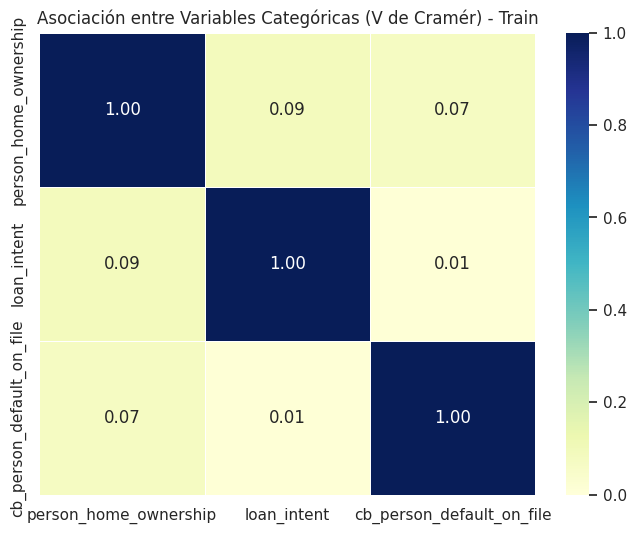


=== ALERTAS DE POSIBLE REDUNDANCIA ===
✔ ¡Todo bien! Ningún par de variables categóricas supera el umbral de riesgo (V > 0.5).


In [ ]:
# =====================================================================
# BLOQUE ADICIONAL: ANÁLISIS DE ASOCIACIÓN CATEGÓRICA (V DE CRAMÉR)
# =====================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """ Calcula el coeficiente V de Cramér para dos variables categóricas. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Corrección de Bias para muestras pequeñas/grandes (Fórmula de Wunderlich)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    # Evitar división por cero si la corrección da estructuras vacías
    if min((kcorr - 1), (rcorr - 1)) == 0:
        return 0.0

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# 1. Recuperar variables categóricas vigentes de X_train
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Construir la matriz de V de Cramér (todos contra todos)
v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            v_matrix.loc[col1, col2] = 1.0  # La asociación consigo misma es perfecta
        else:
            v_matrix.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])

print("=== MATRIZ DE ASOCIACIÓN (V DE CRAMÉR) ===")
display(v_matrix.round(4))

# 3. Representación visual con un Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(v_matrix, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)
plt.title("Asociación entre Variables Categóricas (V de Cramér) - Train")
plt.show()

# 4. Alertas automáticas de redundancia
print("\n=== ALERTAS DE POSIBLE REDUNDANCIA ===")
interesantes = []
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        valor_v = v_matrix.iloc[i, j]
        if valor_v > 0.5:  # Umbral donde la relación empieza a ser muy fuerte
            print(f"⚠ Alerta: Alta asociación entre '{cat_cols[i]}' y '{cat_cols[j]}' (V = {valor_v:.4f})")
            interesantes.append((cat_cols[i], cat_cols[j]))

if not interesantes:
    print("✔ ¡Todo bien! Ningún par de variables categóricas supera el umbral de riesgo (V > 0.5).")

7

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Definimos las categóricas a procesar (las 3 que pasaron el filtro)
cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

# 2. Inicializar OneHotEncoder optimizado
# drop='if_binary': Si una columna solo tiene 2 opciones (como Y/N), crea solo una columna (0 y 1) en vez de dos.
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')

# 3. Ajustar con Train y transformar ambos sets
encoded_train = encoder.fit_transform(X_train[cat_cols])
encoded_test = encoder.transform(X_test[cat_cols])

# 4. Obtener los nombres de las nuevas columnas expandidas
new_col_names = encoder.get_feature_names_out(cat_cols)

# 5. Crear DataFrames temporales con los índices alineados
X_train_encoded = pd.DataFrame(encoded_train, columns=new_col_names, index=X_train.index)
X_test_encoded = pd.DataFrame(encoded_test, columns=new_col_names, index=X_test.index)

# 6. Eliminar columnas de texto originales y acoplar las nuevas columnas numéricas
X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_encoded], axis=1)

print("=== PROCESAMIENTO CATEGÓRICO OPTIMIZADO ===")
print(f"Dimensiones finales del Train: {X_train.shape}")
print(f"Dimensiones finales del Test: {X_test.shape}")
print(f"Nuevas columnas añadidas:\n{list(new_col_names)}")

=== PROCESAMIENTO CATEGÓRICO OPTIMIZADO ===
Dimensiones finales del Train: (22780, 17)
Dimensiones finales del Test: (9760, 17)
Nuevas columnas añadidas:
['person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_Y']


8

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway

# 1. Identificamos las variables que originalmente eran numéricas (excluyendo las que creamos con el One-Hot)
# Un truco fácil es buscar las que no tengan un guion bajo '_' en su nombre, o definirlas a mano:
num_cols_puras = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length']

print("=== REVISIÓN PREVIA DE VARIABLES NUMÉRICAS ===")

for col in num_cols_puras:
    # --- MÉTRICA 1: ANOVA (Diferencia de medias) ---
    # Separamos el grupo de buenos pagadores y malos pagadores
    grupo_0 = X_train.loc[y_train == 0, col]
    grupo_1 = X_train.loc[y_train == 1, col]

    # Prueba F de ANOVA
    f_stat, p_valor_anova = f_oneway(grupo_0, grupo_1)

    # --- MÉTRICA 2: Information Value (IV) mediante Tramos ---
    # Dividimos la variable numérica en 5 tramos (cuantiles) automáticos para poder calcular el IV
    # Usamos qcut con duplicates='drop' por si hay muchos valores repetidos (como en antigüedad laboral)
    try:
        tramos = pd.qcut(X_train[col], q=5, duplicates='drop')
        counts = pd.crosstab(tramos, y_train)
    except ValueError:
        # Si falla qcut por falta de variabilidad, usamos corte lineal (cut)
        tramos = pd.cut(X_train[col], bins=5)
        counts = pd.crosstab(tramos, y_train)

    counts = counts.replace(0, 0.5) # Evitar divisiones por cero

    prob_buenos = counts[0] / counts[0].sum()
    prob_malos = counts[1] / counts[1].sum()

    woe = np.log(prob_buenos / prob_malos)
    iv = ((prob_buenos - prob_malos) * woe).sum()

    # Clasificación estándar del IV
    if iv < 0.02:   fuerza = "Inútil para predecir"
    elif iv < 0.1:  fuerza = "Poder predictivo Débil"
    elif iv < 0.3:  fuerza = "Poder predictivo Mediano"
    else:           fuerza = "Poder predictivo Fuerte"

    print(f"\nVariable Numérica: '{col}'")
    print(f" -> P-Valor (ANOVA): {p_valor_anova:.4e} {'(Medias muy distintas ✔)' if p_valor_anova < 0.05 else '(Medias iguales ❌)'}")
    print(f" -> Information Value (IV): {iv:.4f} ({fuerza})")

=== REVISIÓN PREVIA DE VARIABLES NUMÉRICAS ===

Variable Numérica: 'person_age'
 -> P-Valor (ANOVA): 1.1279e-02 (Medias muy distintas ✔)
 -> Information Value (IV): 0.0059 (Inútil para predecir)

Variable Numérica: 'person_income'
 -> P-Valor (ANOVA): 2.0045e-197 (Medias muy distintas ✔)
 -> Information Value (IV): 0.4625 (Poder predictivo Fuerte)

Variable Numérica: 'person_emp_length'
 -> P-Valor (ANOVA): 2.5261e-37 (Medias muy distintas ✔)
 -> Information Value (IV): 0.0485 (Poder predictivo Débil)

Variable Numérica: 'loan_amnt'
 -> P-Valor (ANOVA): 8.0201e-59 (Medias muy distintas ✔)
 -> Information Value (IV): 0.0758 (Poder predictivo Débil)

Variable Numérica: 'loan_percent_income'
 -> P-Valor (ANOVA): 0.0000e+00 (Medias muy distintas ✔)
 -> Information Value (IV): 0.7070 (Poder predictivo Fuerte)

Variable Numérica: 'cb_person_cred_hist_length'
 -> P-Valor (ANOVA): 1.3355e-01 (Medias iguales ❌)
 -> Information Value (IV): 0.0040 (Inútil para predecir)


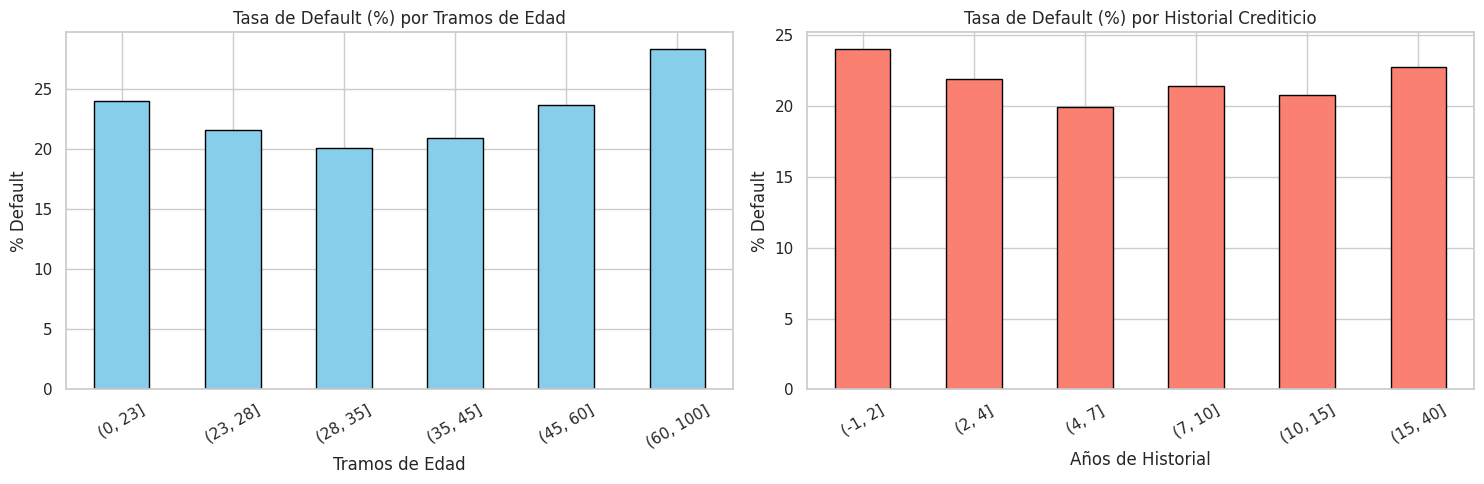

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Gráfico 1: Relación de la Edad con el Default
plt.subplot(1, 2, i:=1)
# Creamos tramos de edad manuales y lógicos para ver la tasa de default
edad_bins = pd.cut(X_train['person_age'], bins=[0, 23, 28, 35, 45, 60, 100])
tasa_edad = y_train.groupby(edad_bins, observed=False).mean() * 100
tasa_edad.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Tasa de Default (%) por Tramos de Edad')
plt.ylabel('% Default')
plt.xlabel('Tramos de Edad')
plt.xticks(rotation=30)

# Gráfico 2: Relación del Historial Crediticio con el Default
plt.subplot(1, 2, 2)
hist_bins = pd.cut(X_train['cb_person_cred_hist_length'], bins=[-1, 2, 4, 7, 10, 15, 40])
tasa_hist = y_train.groupby(hist_bins, observed=False).mean() * 100
tasa_hist.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Tasa de Default (%) por Historial Crediticio')
plt.ylabel('% Default')
plt.xlabel('Años de Historial')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

=== MATRIZ DE CORRELACIÓN DE SPEARMAN (Variables Sobrevivientes) ===


,person_income,person_emp_length,loan_amnt,loan_percent_income
person_income,1.0000,0.2067,0.4039,-0.3695
person_emp_length,0.2067,1.0000,0.1081,-0.0556
loan_amnt,0.4039,0.1081,1.0000,0.6536
loan_percent_income,-0.3695,-0.0556,0.6536,1.0000


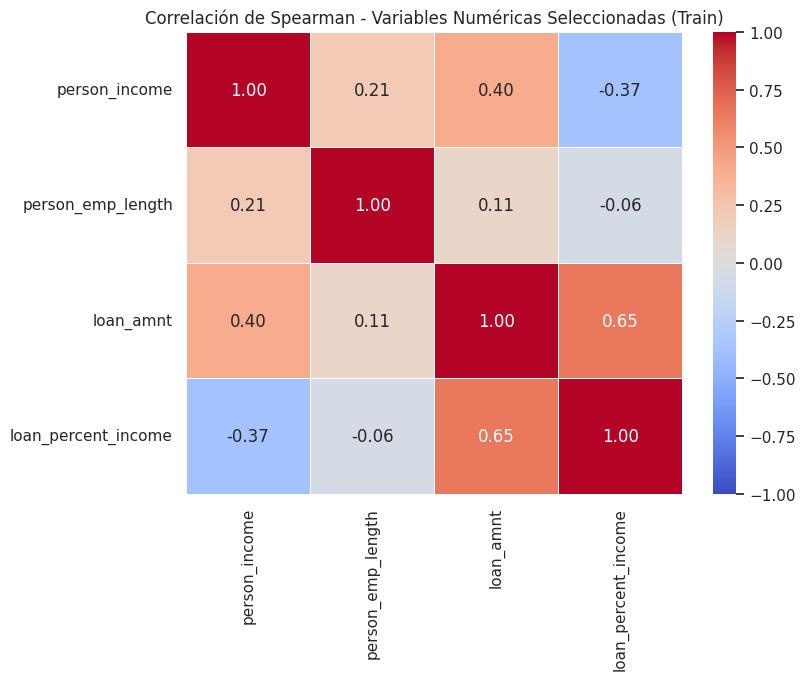


=== ALERTAS DE ALTA CORRELACIÓN (REDUNDANCIA) ===
✔ ¡Todo bien! Ningún par de variables numéricas supera el umbral de redundancia crítica (|R| > 0.7).


In [ ]:
# =====================================================================
# BLOQUE ADICIONAL: ANÁLISIS DE REDUNDANCIA NUMÉRICA (SPEARMAN)
# =====================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtramos solo las variables numéricas que demostraron poder predictivo (Débil o Fuerte)
num_sobrevivientes = ['person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income']

# 2. Calcular la matriz de correlación de Spearman
# Usamos el método 'spearman' explícitamente
spearman_matrix = X_train[num_sobrevivientes].corr(method='spearman')

print("=== MATRIZ DE CORRELACIÓN DE SPEARMAN (Variables Sobrevivientes) ===")
display(spearman_matrix.round(4))

# 3. Representación visual con un Heatmap
plt.figure(figsize=(8, 6))
# Usamos una paleta divergente 'coolwarm' centrada en 0 para identificar relaciones fuertes (+ o -)
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlación de Spearman - Variables Numéricas Seleccionadas (Train)")
plt.show()

# 4. Alertas automáticas de multicolinealidad / redundancia
print("\n=== ALERTAS DE ALTA CORRELACIÓN (REDUNDANCIA) ===")
redundantes = []
for i in range(len(num_sobrevivientes)):
    for j in range(i + 1, len(num_sobrevivientes)):
        valor_corr = spearman_matrix.iloc[i, j]
        # Un umbral de 0.7 o superior indica que una variable explica casi lo mismo que la otra
        if abs(valor_corr) > 0.7:
            print(f"⚠ Alerta: Alta correlación entre '{num_sobrevivientes[i]}' y '{num_sobrevivientes[j]}' (R = {valor_corr:.4f})")
            redundantes.append((num_sobrevivientes[i], num_sobrevivientes[j]))

if not redundantes:
    print("✔ ¡Todo bien! Ningún par de variables numéricas supera el umbral de redundancia crítica (|R| > 0.7).")

9

In [ ]:
# Definimos las variables numéricas que el análisis demostró que son inútiles
cols_a_eliminar = ['person_age', 'cb_person_cred_hist_length']

# Aplicamos la eliminación en Train y Test simultáneamente (Cero Leakage)
X_train = X_train.drop(columns=cols_a_eliminar)
X_test = X_test.drop(columns=cols_a_eliminar)

print("=== DEPURACIÓN NUMÉRICA FINALIZADA ===")
print(f"Variables eliminadas por falta de poder predictivo: {cols_a_eliminar}")
print(f"Dimensiones finales para entrenar -> X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"\nLista definitiva de variables predictoras que irán al modelo:\n{list(X_train.columns)}")

=== DEPURACIÓN NUMÉRICA FINALIZADA ===
Variables eliminadas por falta de poder predictivo: ['person_age', 'cb_person_cred_hist_length']
Dimensiones finales para entrenar -> X_train: (22780, 15) | X_test: (9760, 15)

Lista definitiva de variables predictoras que irán al modelo:
['person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_Y']


10

In [ ]:
# === INSPECCIÓN FINAL DEL DATASET DE ENTRENAMIENTO ===
print(" 1. DIMENSIONES FINALES")
print(f"Características (X_train): {X_train.shape} filas y columnas")
print(f"Variable Objetivo (y_train): {y_train.shape} filas\n")

print(" 2. TIPOS DE DATOS Y VALORES NULOS POR COLUMNA")
# Creamos un resumen estructurado para verificar que todo sea numérico (float o int) y esté limpio
resumen_final = pd.DataFrame({
    'Tipo de Dato': X_train.dtypes,
    'Valores Nulos': X_train.isnull().sum(),
    '% Nulos': (X_train.isnull().sum() / len(X_train)) * 100
})
display(resumen_final)

print("\n 3. VISTA PREVIA DE LOS PRIMEROS 5 REGISTROS")
# Mostramos las primeras filas para asegurarnos de que visualmente todo tenga sentido
display(X_train.head())

 1. DIMENSIONES FINALES
Características (X_train): (22780, 15) filas y columnas
Variable Objetivo (y_train): (22780,) filas

 2. TIPOS DE DATOS Y VALORES NULOS POR COLUMNA


,Tipo de Dato,Valores Nulos,% Nulos
person_income,int64,0,0.0
person_emp_length,float64,0,0.0
loan_amnt,int64,0,0.0
loan_percent_income,float64,0,0.0
person_home_ownership_MORTGAGE,float64,0,0.0
person_home_ownership_OTHER,float64,0,0.0
person_home_ownership_OWN,float64,0,0.0
person_home_ownership_RENT,float64,0,0.0
loan_intent_DEBTCONSOLIDATION,float64,0,0.0
loan_intent_EDUCATION,float64,0,0.0



 3. VISTA PREVIA DE LOS PRIMEROS 5 REGISTROS


,person_income,person_emp_length,loan_amnt,loan_percent_income,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
11491,62000,1.0,10000,0.16,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3890,39000,3.0,5000,0.13,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
17344,35000,1.0,12000,0.34,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13023,86000,1.0,12000,0.14,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
29565,38400,4.0,13000,0.34,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


11

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# 1. Inicializar el contenedor global de resultados (si no existe)
if 'resultados_modelos' not in locals():
    resultados_modelos = {}

print("=== ENTRENANDO MODELO 1: REGRESIÓN LOGÍSTICA ===")

# 2. Crear el Pipeline (Escalador + Modelo)
# Usamos max_iter=1000 para asegurar que el algoritmo converja matemáticamente sin problemas
logistic_pipeline = Pipeline([
    ('escalador', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

# 3. Entrenar el modelo en el set de datos
logistic_pipeline.fit(X_train, y_train)

# 4. Realizar predicciones en el set de prueba (Test)
y_pred = logistic_pipeline.predict(X_test)
y_pred_proba = logistic_pipeline.predict_proba(X_test)[:, 1] # Probabilidades para el cálculo del AUC-ROC

# 5. Calcular métricas clave de evaluación para riesgo crediticio
auc_roc = roc_auc_score(y_test, y_pred_proba)
f1_default = f1_score(y_test, y_pred, pos_label=1) # F1-Score específico para capturar los Default (Clase 1)

# 6. Guardar métricas en nuestro contenedor comparativo
resultados_modelos['Regresion_Logistica'] = {
    'AUC-ROC': round(auc_roc, 4),
    'F1-Score (Default)': round(f1_default, 4)
}

# 7. Mostrar reporte completo en pantalla
print("\n📋 Reporte de Clasificación en Test:")
print(classification_report(y_test, y_pred))
print(f"🏅 AUC-ROC Score: {auc_roc:.4f}")
print("================================================")

=== ENTRENANDO MODELO 1: REGRESIÓN LOGÍSTICA ===

📋 Reporte de Clasificación en Test:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      7629
           1       0.74      0.39      0.51      2131

    accuracy                           0.84      9760
   macro avg       0.80      0.68      0.71      9760
weighted avg       0.83      0.84      0.82      9760

🏅 AUC-ROC Score: 0.8071


12

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

print("=== ENTRENANDO MODELO 2: RANDOM FOREST ===")

# 1. Inicializar el modelo
# Usamos n_estimators=100 (100 árboles) y fijamos el random_state para que el experimento sea replicable
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Entrenar el modelo directamente con los datos puros (No requiere escalado)
rf_model.fit(X_train, y_train)

# 3. Realizar predicciones en el set de prueba (Test)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. Calcular métricas clave
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)
f1_default_rf = f1_score(y_test, y_pred_rf, pos_label=1)

# 5. Guardar métricas en el contenedor global
resultados_modelos['Random_Forest'] = {
    'AUC-ROC': round(auc_roc_rf, 4),
    'F1-Score (Default)': round(f1_default_rf, 4)
}

# 6. Mostrar reporte completo en pantalla
print("\n📋 Reporte de Clasificación en Test (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print(f"🏅 AUC-ROC Score: {auc_roc_rf:.4f}")
print("================================================")

=== ENTRENANDO MODELO 2: RANDOM FOREST ===

📋 Reporte de Clasificación en Test (Random Forest):
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      7629
           1       0.84      0.55      0.67      2131

    accuracy                           0.88      9760
   macro avg       0.86      0.76      0.80      9760
weighted avg       0.88      0.88      0.87      9760

🏅 AUC-ROC Score: 0.8593


13

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

print("=== ENTRENANDO MODELO 3: ADABOOST ===")

# 1. Inicializar el modelo
# Usamos n_estimators=100 y un random_state fijo para asegurar la replicabilidad
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo con los datos
adaboost_model.fit(X_train, y_train)

# 3. Realizar predicciones en el set de prueba (Test)
y_pred_ada = adaboost_model.predict(X_test)
y_pred_proba_ada = adaboost_model.predict_proba(X_test)[:, 1]

# 4. Calcular métricas clave
auc_roc_ada = roc_auc_score(y_test, y_pred_proba_ada)
f1_default_ada = f1_score(y_test, y_pred_ada, pos_label=1)

# 5. Guardar métricas en el contenedor global
resultados_modelos['AdaBoost'] = {
    'AUC-ROC': round(auc_roc_ada, 4),
    'F1-Score (Default)': round(f1_default_ada, 4)
}

# 6. Mostrar reporte completo en pantalla
print("\n📋 Reporte de Clasificación en Test (AdaBoost):")
print(classification_report(y_test, y_pred_ada))
print(f"🏅 AUC-ROC Score: {auc_roc_ada:.4f}")
print("================================================")

=== ENTRENANDO MODELO 3: ADABOOST ===

📋 Reporte de Clasificación en Test (AdaBoost):
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      7629
           1       0.77      0.48      0.59      2131

    accuracy                           0.85      9760
   macro avg       0.82      0.72      0.75      9760
weighted avg       0.85      0.85      0.84      9760

🏅 AUC-ROC Score: 0.8403


14

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

print("=== ENTRENANDO MODELO 4: GRADIENT BOOSTING ===")

# 1. Inicializar el modelo
# Usamos n_estimators=100 y fijamos random_state para consistencia
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo
gb_model.fit(X_train, y_train)

# 3. Realizar predicciones en el set de prueba (Test)
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# 4. Calcular métricas clave
auc_roc_gb = roc_auc_score(y_test, y_pred_proba_gb)
f1_default_gb = f1_score(y_test, y_pred_gb, pos_label=1)

# 5. Guardar métricas en el contenedor global
resultados_modelos['Gradient_Boosting'] = {
    'AUC-ROC': round(auc_roc_gb, 4),
    'F1-Score (Default)': round(f1_default_gb, 4)
}

# 6. Mostrar reporte completo en pantalla
print("\n📋 Reporte de Clasificación en Test (Gradient Boosting):")
print(classification_report(y_test, y_pred_gb))
print(f"🏅 AUC-ROC Score: {auc_roc_gb:.4f}")
print("================================================")

=== ENTRENANDO MODELO 4: GRADIENT BOOSTING ===

📋 Reporte de Clasificación en Test (Gradient Boosting):
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      7629
           1       0.96      0.50      0.66      2131

    accuracy                           0.89      9760
   macro avg       0.92      0.75      0.79      9760
weighted avg       0.90      0.89      0.87      9760

🏅 AUC-ROC Score: 0.8831


15

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

print("=== ENTRENANDO MODELO 5: XGBOOST ===")

# 1. Inicializar el modelo
# Usamos n_estimators=100 y fijamos random_state.
# eval_metric='logloss' evita alertas innecesarias en las versiones recientes de XGBoost
xgboost_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)

# 2. Entrenar el modelo con los datos puros
xgboost_model.fit(X_train, y_train)

# 3. Realizar predicciones en el set de prueba (Test)
y_pred_xgb = xgboost_model.predict(X_test)
y_pred_proba_xgb = xgboost_model.predict_proba(X_test)[:, 1]

# 4. Calcular métricas clave
auc_roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
f1_default_xgb = f1_score(y_test, y_pred_xgb, pos_label=1)

# 5. Guardar métricas en el contenedor global
resultados_modelos['XGBoost'] = {
    'AUC-ROC': round(auc_roc_xgb, 4),
    'F1-Score (Default)': round(f1_default_xgb, 4)
}

# 6. Mostrar reporte completo en pantalla
print("\n📋 Reporte de Clasificación en Test (XGBoost):")
print(classification_report(y_test, y_pred_xgb))
print(f"🏅 AUC-ROC Score: {auc_roc_xgb:.4f}")
print("================================================")

=== ENTRENANDO MODELO 5: XGBOOST ===

📋 Reporte de Clasificación en Test (XGBoost):
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7629
           1       0.89      0.59      0.71      2131

    accuracy                           0.90      9760
   macro avg       0.89      0.79      0.82      9760
weighted avg       0.90      0.90      0.89      9760

🏅 AUC-ROC Score: 0.9029


16

🏆   MÉTRICAS DETALLADAS DE CLASIFICACIÓN (CLASE 1)   🏆



,AUC-ROC,Precision (Clase 1),Recall (Clase 1)
XGBoost,0.9029,0.8935,0.5903
Gradient_Boosting,0.8831,0.9628,0.4984
Random_Forest,0.8593,0.8370,0.5542
AdaBoost,0.8403,0.7678,0.4796
Regresion_Logistica,0.8071,0.7444,0.3909



📊 GENERANDO COMPARATIVA VISUAL: PRECISION VS RECALL...


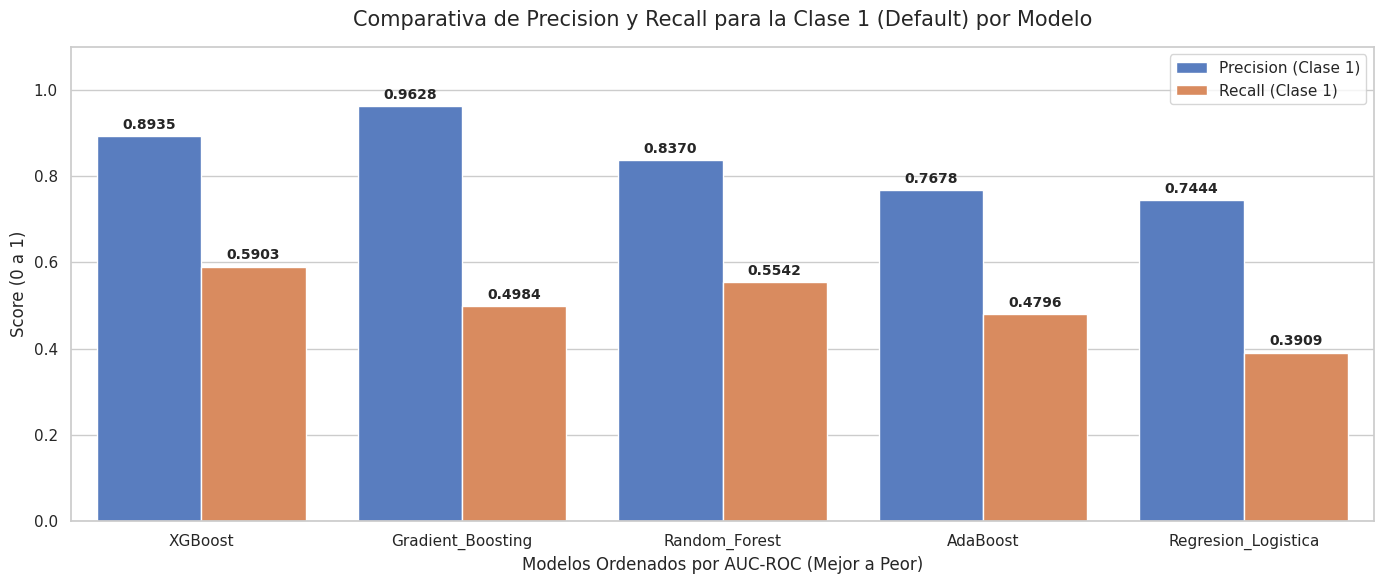

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, roc_auc_score

print("====================================================")
print("🏆   MÉTRICAS DETALLADAS DE CLASIFICACIÓN (CLASE 1)   🏆")
print("====================================================\n")

# 1. Creamos un nuevo contenedor para el desglose detallado
resultados_detallados = {}

# Lista de tus modelos entrenados en las celdas anteriores
# Mapeamos el nombre que usaremos con el objeto real del modelo y si necesita pipeline (escalado) o no
modelos_dict = {
    'Regresion_Logistica': (logistic_pipeline, True),
    'Random_Forest': (rf_model, False),
    'AdaBoost': (adaboost_model, False),
    'Gradient_Boosting': (gb_model, False),
    'XGBoost': (xgboost_model, False)
}

# 2. Extraer Precision, Recall y AUC-ROC simétricamente para la Clase 1 (Default)
for nombre, (modelo_obj, requiere_pipeline) in modelos_dict.items():
    # Predicciones
    y_pred = modelo_obj.predict(X_test)
    y_pred_proba = modelo_obj.predict_proba(X_test)[:, 1]

    # Cálculo de métricas específicas
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    precision_clase1 = precision_score(y_test, y_pred, pos_label=1)
    recall_clase1 = recall_score(y_test, y_pred, pos_label=1)

    # Guardar en el nuevo DataFrame
    resultados_detallados[nombre] = {
        'AUC-ROC': round(auc_roc, 4),
        'Precision (Clase 1)': round(precision_clase1, 4),
        'Recall (Clase 1)': round(recall_clase1, 4)
    }

# 3. Convertir a DataFrame y ordenar por AUC-ROC
df_detallado = pd.DataFrame.from_dict(resultados_detallados, orient='index')
df_detallado = df_detallado.sort_values(by='AUC-ROC', ascending=False)

# Mostrar la tabla en limpio
display(df_detallado)

print("\n📊 GENERANDO COMPARATIVA VISUAL: PRECISION VS RECALL...")

# 4. Gráfico de barras doble para comparar el Trade-off de Precision y Recall
# Derretimos el dataframe para adaptarlo al formato que le gusta a Seaborn (long-format)
df_melted = df_detallado.reset_index().melt(
    id_vars='index',
    value_vars=['Precision (Clase 1)', 'Recall (Clase 1)'],
    var_name='Métrica',
    value_name='Score'
).rename(columns={'index': 'Modelos'})

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Dibujar las barras agrupadas
ax = sns.barplot(data=df_melted, x='Modelos', y='Score', hue='Métrica', palette='muted')

plt.title('Comparativa de Precision y Recall para la Clase 1 (Default) por Modelo', fontsize=15, pad=15)
plt.ylabel('Score (0 a 1)')
plt.xlabel('Modelos Ordenados por AUC-ROC (Mejor a Peor)')
plt.ylim(0, 1.1)
plt.legend(loc='upper right')

# Añadir etiquetas de texto sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Evitar pintar textos en barras vacías si las hay
        ax.annotate(f"{height:.4f}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

17

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, classification_report

print("=== OPTIMIZACIÓN DE UMBRAL (ANTI-OVERFITTING) ===")

# 1. Obtener las probabilidades del Train usando Validación Cruzada (5-Folds)
# Esto evita que el modelo "recuerde" sus propios datos y sesgue el umbral
y_train_pred_proba = cross_val_predict(
    xgboost_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

# 2. Evaluar diferentes umbrales en el Train para encontrar el óptimo
umbrales = np.linspace(0.1, 0.9, 81)
resultados_umbrales = []

for u in umbrales:
    y_pred_temporal = (y_train_pred_proba >= u).astype(int)
    p = precision_score(y_train, y_pred_temporal, pos_label=1, zero_division=0)
    r = recall_score(y_train, y_pred_temporal, pos_label=1, zero_division=0)
    resultados_umbrales.append({'Umbral': u, 'Precision': p, 'Recall': r})

df_umbrales = pd.DataFrame(resultados_umbrales)

# 3. Criterio de Selección del Umbral Óptimo:
# Queremos el Recall más alto posible, pero exigiendo que la Precision NO baje del 70%
# (para no inundar al banco con falsos positivos comerciales).
filtro_seguro = df_umbrales[df_umbrales['Precision'] >= 0.70]

if not filtro_seguro.empty:
    # De los que cumplen el piso de Precision, elegimos el de mayor Recall
    umbral_optimo = filtro_seguro.sort_values(by='Recall', ascending=False).iloc[0]['Umbral']
else:
    # Si ninguno cumple (raro), elegimos el punto donde se cruzan
    df_umbrales['diff'] = abs(df_umbrales['Precision'] - df_umbrales['Recall'])
    umbral_optimo = df_umbrales.sort_values(by='diff').iloc[0]['Umbral']

print(f"\n Umbral óptimo seleccionado mediante CV en Train: {umbral_optimo:.2f}")

# 4. APLICACIÓN DEL UMBRAL GANADOR EN EL SET DE PRUEBA (TEST)
# Tomamos las probabilidades del Test que ya calculamos en la Celda 15 (y_pred_proba_xgb)
y_pred_test_optimo = (y_pred_proba_xgb >= umbral_optimo).astype(int)

# 5. Calcular nuevas métricas en Test
precision_final = precision_score(y_test, y_pred_test_optimo, pos_label=1)
recall_final = recall_score(y_test, y_pred_test_optimo, pos_label=1)

print("\n================================================")
print(" RESULTADOS FINALES EN TEST CON NUEVO UMBRAL")
print("================================================")
print(f"🔹 Umbral Anterior: 0.50 | Nuevo Umbral: {umbral_optimo:.2f}")
print(f" RECALL FINAL:     {recall_final:.4f} (Antes: 0.5903)")
print(f" PRECISION FINAL:  {precision_final:.4f} (Antes: 0.8935)")
print("\n Reporte de Clasificación Actualizado:")
print(classification_report(y_test, y_pred_test_optimo))

=== OPTIMIZACIÓN DE UMBRAL (ANTI-OVERFITTING) ===

 Umbral óptimo seleccionado mediante CV en Train: 0.31

 RESULTADOS FINALES EN TEST CON NUEVO UMBRAL
🔹 Umbral Anterior: 0.50 | Nuevo Umbral: 0.31
 RECALL FINAL:     0.7058 (Antes: 0.5903)
 PRECISION FINAL:  0.7326 (Antes: 0.8935)

 Reporte de Clasificación Actualizado:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7629
           1       0.73      0.71      0.72      2131

    accuracy                           0.88      9760
   macro avg       0.83      0.82      0.82      9760
weighted avg       0.88      0.88      0.88      9760



18

In [ ]:
import joblib
import os

print("====================================================")
print("         EXPORTACIÓN DEL MODELO GANADOR             ")
print("====================================================\n")

# 1. Definimos la estructura del artefacto de producción
artefacto_produccion = {
    'modelo_xgboost': xgboost_model,
    'umbral_optimo': 0.31,
    'variables_entrenamiento': list(X_train.columns)
}

# 2. Definimos el nombre del archivo
nombre_archivo = "modelo_riesgo_crediticio_xgb.pkl"

# 3. Exportamos el artefacto utilizando joblib
joblib.dump(artefacto_produccion, nombre_archivo)

# 4. Verificación de éxito
if os.path.exists(nombre_archivo):
    tamano_mb = os.path.getsize(nombre_archivo) / (1024 * 1024)
    print(f" ¡Artefacto exportado con éxito!")
    print(f" Nombre del archivo: '{nombre_archivo}'")
    print(f"  Tamaño en disco:   {tamano_mb:.2f} MB")
    print("\n Nota: Este archivo ya incluye el modelo, las columnas correctas y tu umbral calibrado de 0.31.")
else:
    print(" Hubo un problema al exportar el archivo. Verifica los permisos de tu entorno.")

💾        EXPORTACIÓN DEL MODELO GANADOR            🏆

✅ ¡Artefacto exportado con éxito!
📁 Nombre del archivo: 'modelo_riesgo_crediticio_xgb.pkl'
⚖️  Tamaño en disco:   0.31 MB

💡 Nota: Este archivo ya incluye el modelo, las columnas correctas y tu umbral calibrado de 0.31.
